In [7]:
import os
import json
from openai import OpenAI
from dotenv import load_dotenv
import gradio as gr
import sqlite3


load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "gpt-4.1-mini"
openai = OpenAI()

DB = "prices.db"


OpenAI API Key exists and begins sk-proj-


In [8]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [40]:
def get_book_price(book):
    with sqlite3.connect(DB) as conn:
       cursor = conn.cursor()
       cursor.execute('SELECT price FROM prices WHERE book = ?', (book.lower(),))
       result = cursor.fetchone()
       return f"The {book} price is ${result[0]}" if result else "No price data available for this book"
    

In [41]:
price_function = {
    "name" : "get_book_price",
    "description" : "Get the price of the book",
    "parameters":{
        "type" : "object",
        "properties" : {
           "book": {
            "type" : "string",
            "description" : "The price of the book",
           },
        },
         "required" : ["book"],
        "additionalParameters" : False,
    }
}

tools = [{"type": "function", "function": price_function}]
tools


[{'type': 'function',
  'function': {'name': 'get_book_price',
   'description': 'Get the price of the book',
   'parameters': {'type': 'object',
    'properties': {'book': {'type': 'string',
      'description': 'The price of the book'}},
    'required': ['book'],
    'additionalParameters': False}}}]

In [42]:
def handle_tool_calls_and_return_books(message):
    responses = []
    books = []
    for tool_call in message.tool_calls:
        arguments = json.loads(tool_call.function.arguments)
        book = arguments.get('book')
        books.append(book)
        price_details = get_book_price(book)
        responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses,books


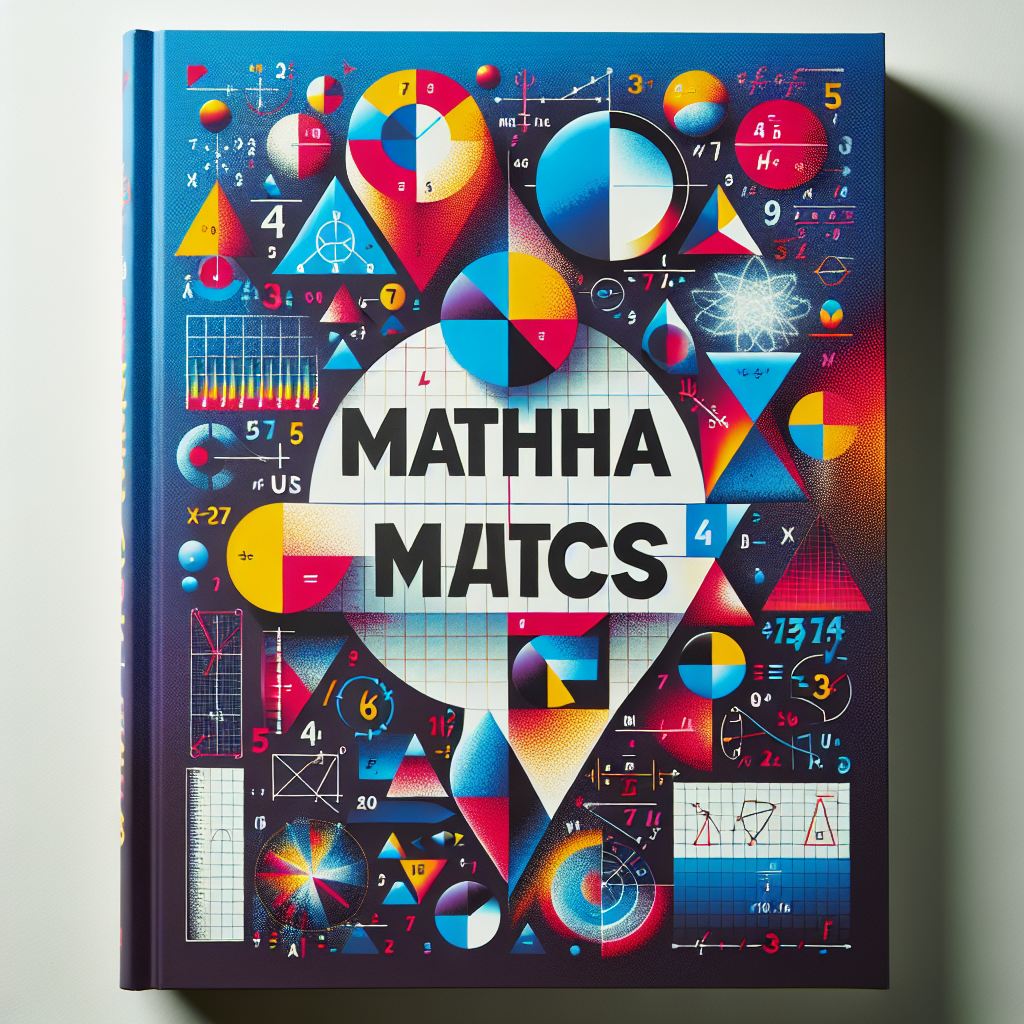

In [36]:
from io import BytesIO
from PIL import Image
import base64

def artist(book):
    image_response = openai.images.generate(
        model = "dall-e-3",
        prompt = f"An image representing a {book} book, showing  title of book and author" ,
        size = "1024x1024",
        n=1,
        response_format = "b64_json",
    )
    image_b64 = image_response.data[0].b64_json
    image_decode = base64.b64decode(image_b64)
    return Image.open(BytesIO(image_decode))

image = artist("Maths Book")
display(image)


In [43]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [44]:
def chat(history):
    history = [{"role" : h["role"], "content" : h["content"]} for h in history]
    messages = ([{"role" : "system","content": system_message}]
     + history )
    books = []
    image = None


    response = openai.chat.completions.create(model = MODEL, messages = messages, tools = tools)

    if response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses,books = handle_tool_calls_and_return_books(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model = MODEL, messages = messages,tools = tools)
    
    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if books:
        image = artist(books[0])
    
    return history, voice, image


In [45]:
def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.
